# PAMAP2 Human Activity Recognition (HAR) - Full Pipeline

## Overview
This notebook implements a complete end-to-end machine learning pipeline for Human Activity Recognition (HAR) using the PAMAP2 dataset. The pipeline includes:

- **Data Loading & Preprocessing**: Loading raw sensor data and defining activity labels
- **Data Cleaning**: Handling duplicates, missing values, and outliers
- **Signal Processing**: Filtering gravity and noise from IMU sensor data
- **Feature Engineering**: Creating sliding windows and extracting statistical features
- **Model Training**: Training and comparing multiple classifiers (LR, SVM, Random Forest)
- **Evaluation**: Leave-One-Group-Out (LOGO) cross-validation for subject-independent evaluation

## Dataset: PAMAP2
The PAMAP2 (Physical Activity Monitoring) dataset contains data from multiple subjects performing different activities using three IMU sensors (hand, chest, ankle). Each sensor records:
- 3-axis accelerometer data (16-bit and 6-bit resolution)
- Gyroscope data (3-axis rotation rates)
- Magnetometer data (magnetic field)
- Temperature readings

## Key Pipeline Steps
1. Parse raw sensor files and assign activity labels
2. Clean sensor data (remove duplicates, handle missing values, detect outliers)
3. Filter noise and gravity component from acceleration using low-pass butterworth filter
4. Create overlapping sliding windows (window size: 200 samples ≈ 2 sec @ 100Hz)
5. Extract 50+ statistical and spectral features per sensor per window
6. Train classifiers using Leave-One-Group-Out cross-validation (subject-independent)

In [1]:
# ==================== REQUIRED LIBRARIES ====================

# Data manipulation and analysis
import pandas as pd
from pathlib import Path

# Visualization
import seaborn as sns
from matplotlib import pyplot as plt

# Scientific computing (imported later in pipeline but listed here for completeness)
import numpy as np  # For numerical operations
from scipy.signal import butter, filtfilt  # For signal filtering
from scipy import stats  # For statistical computations

# Dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE # For 2D visualization

# Models 
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

## Step 1: Define Sensor Columns & Activity Mapping

The PAMAP2 raw data files (.dat) contain sensor readings in a specific order. We define the exact column names and activity labels here.

In [2]:
# Column names corresponding to PAMAP2 dataset structure
# Each row in the .dat files has this exact order of values

columns = [
    # Timestamp - marks when the measurement was taken
    'timestamp',

    # Activity indicator - identifies what activity was performed
    'activity_id',

    # Heart rate measurement (note: will be removed later due to high missing rate)
    'heart_rate',

    # ===== HAND SENSOR (right wrist) =====
    'imu_hand_temperature',
    # Accelerometer 16-bit (higher resolution, captures all movements)
    'imu_hand_accel_16_x',
    'imu_hand_accel_16_y',
    'imu_hand_accel_16_z',
    # Accelerometer 6-bit (low resolution variant)
    'imu_hand_accel_6_x',
    'imu_hand_accel_6_y',
    'imu_hand_accel_6_z',
    # Gyroscope (angular velocity / rotation rates)
    'imu_hand_gyro_x',
    'imu_hand_gyro_y',
    'imu_hand_gyro_z',
    # Magnetometer (magnetic field components)
    'imu_hand_magnet_x',
    'imu_hand_magnet_y',
    'imu_hand_magnet_z',
    # Orientation (quaternion representation of 3D orientation)
    'imu_hand_orientation_1',
    'imu_hand_orientation_2',
    'imu_hand_orientation_3',
    'imu_hand_orientation_4',

    # ===== CHEST SENSOR =====
    'imu_chest_temperature',
    'imu_chest_accel_16_x',
    'imu_chest_accel_16_y',
    'imu_chest_accel_16_z',
    'imu_chest_accel_6_x',
    'imu_chest_accel_6_y',
    'imu_chest_accel_6_z',
    'imu_chest_gyro_x',
    'imu_chest_gyro_y',
    'imu_chest_gyro_z',
    'imu_chest_magnet_x',
    'imu_chest_magnet_y',
    'imu_chest_magnet_z',
    'imu_chest_orientation_1',
    'imu_chest_orientation_2',
    'imu_chest_orientation_3',
    'imu_chest_orientation_4',

    # ===== ANKLE SENSOR =====
    'imu_ankle_temperature',
    'imu_ankle_accel_16_x',
    'imu_ankle_accel_16_y',
    'imu_ankle_accel_16_z',
    'imu_ankle_accel_6_x',
    'imu_ankle_accel_6_y',
    'imu_ankle_accel_6_z',
    'imu_ankle_gyro_x',
    'imu_ankle_gyro_y',
    'imu_ankle_gyro_z',
    'imu_ankle_magnet_x',
    'imu_ankle_magnet_y',
    'imu_ankle_magnet_z',
    'imu_ankle_orientation_1',
    'imu_ankle_orientation_2',
    'imu_ankle_orientation_3',
    'imu_ankle_orientation_4',
]

# ==================== ACTIVITY MAPPING ====================
# Maps numeric activity IDs to human-readable labels
# Used throughout the pipeline for labeling and visualization
activities = {
    0: 'Other',  # Miscellaneous/unlabeled activity
    1: 'Lying',
    2: 'Sitting',
    3: 'Standing',
    4: 'Walking',
    5: 'Running',
    6: 'Cycling',
    7: 'Nordic Walking',
    9: 'Watching TV',
    10: 'Computer Work',
    11: 'Car Driving',
    12: 'Ascending Stairs',
    13: 'Descending Stairs',
    16: 'Vacuum Cleaning',
    17: 'Ironing',
    18: 'Folding Laundry',
    19: 'House Cleaning',
    20: 'Playing Soccer',
    24: 'Rope Jumping'
}

In [3]:
def load_pamap2_dataset(dataset_dir='../data/PAMAP2_Dataset'):
    """
    Load PAMAP2 dataset files from both Protocol and Optional folders.
    
    Parameters:
    -----------
    dataset_dir : str
        Path to the PAMAP2_Dataset directory
        
    Returns:
    --------
    protocol_df : pd.DataFrame
        DataFrame with protocol recordings (structured activities)
    optional_df : pd.DataFrame
        DataFrame with optional recordings (ad-hoc activities)
    combined_df : pd.DataFrame
        DataFrame combining both protocol and optional recordings
    """
    
    # Create Path object for easy file globbing
    dataset_path = Path(dataset_dir)
    
    # Find all subject files (.dat format) in both folders
    protocol_files = sorted(dataset_path.glob('Protocol/subject*.dat'))
    optional_files = sorted(dataset_path.glob('Optional/subject*.dat'))
    
    # Initialize lists to store DataFrames before concatenation
    dfs_protocol = []
    dfs_optional = []
    
    # ===== LOAD PROTOCOL FILES =====
    # Each file contains data from one subject performing structured activities
    for file in protocol_files:
        # Read space-separated values (no header in raw files)
        df = pd.read_csv(file, sep=' ', header=None)
        
        # Assign column names based on our predefined column list
        # Note: columns are assigned in order, and extra columns are ignored
        df.columns = columns[:df.shape[1]]
        
        # Extract subject ID from filename (e.g., "subject101.dat" → 101)
        df['subject_id'] = int(file.stem.replace('subject', ''))
        
        dfs_protocol.append(df)
    
    # ===== LOAD OPTIONAL FILES =====
    # Similar process for optional recordings
    for file in optional_files:
        df = pd.read_csv(file, sep=' ', header=None)
        df.columns = columns[:df.shape[1]]
        df['subject_id'] = int(file.stem.replace('subject', ''))
        dfs_optional.append(df)
    
    # ===== CONCATENATE DATAFRAMES =====
    # Combine all files of each type, resetting index
    protocol_df = pd.concat(dfs_protocol, ignore_index=True)
    optional_df = pd.concat(dfs_optional, ignore_index=True)
    combined_df = pd.concat(dfs_protocol + dfs_optional, ignore_index=True)
    
    # ===== MAP ACTIVITY IDS TO NAMES =====
    # Add human-readable activity labels to all DataFrames
    for df in [protocol_df, optional_df, combined_df]:
        df['activity_name'] = df['activity_id'].map(activities)
    
    return protocol_df, optional_df, combined_df

## Step 2: Load PAMAP2 Dataset

The dataset is organized into two categories:
- **Protocol**: Predefined activities performed following a specific protocol
- **Optional**: Additional ad-hoc recordings by subjects

We load both and can work with either protocol, optional, or combined data.

### Load and Initialize Data
We load the combined dataset (both protocol and optional recordings) and filter out the 'Other' activity class to focus on well-defined activities.

In [4]:
_, _, df = load_pamap2_dataset()

## Step 3: Data Cleaning

### 3.1: Remove duplicates and unecessary columns :
Eliminate duplicate records (same timestamp, subject, and activity) which can bias the model.

In [5]:
def drop_duplicates(df):
    df = df.drop_duplicates(subset=['timestamp', 'subject_id', 'activity_id'])
    return df

df = drop_duplicates(df)

unnecessary_columns = (
        [col for col in df.columns if '_accel_6_' in col]
        + ['imu_hand_magnet_x', 'imu_hand_magnet_y', 'imu_hand_magnet_z',
           'imu_chest_magnet_x', 'imu_chest_magnet_y', 'imu_chest_magnet_z',
           'imu_ankle_magnet_x', 'imu_ankle_magnet_y', 'imu_ankle_magnet_z',
           'imu_hand_orientation_1', 'imu_hand_orientation_2', 'imu_hand_orientation_3', 'imu_hand_orientation_4',
           'imu_chest_orientation_1', 'imu_chest_orientation_2', 'imu_chest_orientation_3', 'imu_chest_orientation_4']
    )

def drop_activity_and_columns(df, unnecessary_columns, activity_id=0) :
    if activity_id is not None :
        df = df[df['activity_id'] != 0].copy()
        # Remove 'Other' from the activity mapping dictionary as well
        activities.pop(0)
    df = df.drop(columns=unnecessary_columns)
    return df

df = drop_activity_and_columns(df, unnecessary_columns)




### 3.2: Analyze Missing Values
Check for missing data in sensor readings. High missingness in some sensors may require removal or imputation.

In [6]:
# Count missing values (NaN) for each column
# Shows the number of missing samples for each sensor/metric
missing_counts = df.isna().mean().round(4) * 100
print("Missing values per column:")
print(missing_counts[missing_counts > 0])  # Only show columns with missing values

Missing values per column:
heart_rate                 90.87
imu_hand_temperature        0.44
imu_hand_accel_16_x         0.44
imu_hand_accel_16_y         0.44
imu_hand_accel_16_z         0.44
imu_hand_gyro_x             0.44
imu_hand_gyro_y             0.44
imu_hand_gyro_z             0.44
imu_chest_temperature       0.11
imu_chest_accel_16_x        0.11
imu_chest_accel_16_y        0.11
imu_chest_accel_16_z        0.11
imu_chest_gyro_x            0.11
imu_chest_gyro_y            0.11
imu_chest_gyro_z            0.11
imu_ankle_temperature       0.36
imu_ankle_accel_16_x        0.36
imu_ankle_accel_16_y        0.36
imu_ankle_accel_16_z        0.36
imu_ankle_gyro_x            0.36
imu_ankle_gyro_y            0.36
imu_ankle_gyro_z            0.36
imu_ankle_orientation_1     0.36
imu_ankle_orientation_2     0.36
imu_ankle_orientation_3     0.36
imu_ankle_orientation_4     0.36
dtype: float64


### Missing Values Analysis Summary
- **Heart rate**: ~90.87% missing ← Remove this column
- **Hand sensors**: ~0.4% missing
- **Chest sensors**: ~0.11% missing  
- **Ankle sensors**: ~0.36% missing

The heart_rate column has excessive missingness (~91%) and will be dropped. IMU sensors have minimal missingness which will be handled via interpolation.

In [7]:
# Drop heart_rate column due to excessive missing values (~91%)
# This sensor has too little data to be reliable for training
df = df.drop(columns=['heart_rate'])

### 3.3: Handle Missing Values via Interpolation
For remaining missing values in IMU sensors, use linear interpolation within each subject to preserve temporal continuity.

In [8]:
def interpolate_missing(df, sensor_prefix='imu_'):
    """Interpolate missing sensor values per subject for columns starting with sensor_prefix."""
    sensor_cols = [c for c in df.columns if c.startswith(sensor_prefix)]
    df = df.sort_values(['subject_id', 'timestamp'])
    df[sensor_cols] = df.groupby('subject_id')[sensor_cols].transform(lambda x: x.interpolate(method='linear'))
    return df

In [9]:
df = interpolate_missing(df)

In [10]:
# ===== VERIFICATION: Check that all missing values are handled =====
print("Remaining missing values after interpolation:")
remaining_missing = df.isna().sum()
print(f"Total NaN values: {remaining_missing.sum()}")

print(f"\nDataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

Remaining missing values after interpolation:
Total NaN values: 0

Dataset shape: (2724953, 29)
Total rows: 2724953, Total columns: 29


## Temperature vs Activity: Statistical Association Test

**Goal:** determine whether sensor temperature differs significantly across activities.

**Method:** temperature is a continuous variable while `activity_id` is categorical, so a
chi-square test is not the natural fit here (chi-square requires two categorical variables).
Instead we use:

- **ANOVA** - tests whether group means differ, assuming normality and homogeneity of
  variance across activity groups
- **Kruskal-Wallis** - non-parametric alternative, more robust to violations of ANOVA's
  assumptions (likely here, given the skew/outliers observed earlier)

**Caveat:** given the large sample size (~2.7M rows), even tiny, practically irrelevant
differences will likely produce a statistically significant p-value. Eta squared (effect
size) is computed alongside to assess whether the difference is actually meaningful in
magnitude, not just statistically detectable.

In [11]:
from scipy.stats import f_oneway, kruskal

temp_cols = ['imu_hand_temperature', 'imu_chest_temperature', 'imu_ankle_temperature']

for col in temp_cols:
    print(f"\n{'='*60}")
    print(f"Test: {col} vs activity_id")
    print('='*60)
    
    groups = [group[col].dropna().values for name, group in df.groupby('activity_id')]
    
    f_stat, p_anova = f_oneway(*groups)
    print(f"ANOVA  : F = {f_stat:.2f}, p-value = {p_anova:.4e}")
    
    h_stat, p_kw = kruskal(*groups)
    print(f"Kruskal: H = {h_stat:.2f}, p-value = {p_kw:.4e}")
    
    if p_kw < 0.05:
        print("=> Temperature differs significantly across activities")
    else:
        print("=> No significant difference across activities")


Test: imu_hand_temperature vs activity_id
ANOVA  : F = 184230.60, p-value = 0.0000e+00
Kruskal: H = 1278395.66, p-value = 0.0000e+00
=> Temperature differs significantly across activities

Test: imu_chest_temperature vs activity_id
ANOVA  : F = 148392.36, p-value = 0.0000e+00
Kruskal: H = 1168844.82, p-value = 0.0000e+00
=> Temperature differs significantly across activities

Test: imu_ankle_temperature vs activity_id
ANOVA  : F = 124974.19, p-value = 0.0000e+00
Kruskal: H = 1170829.22, p-value = 0.0000e+00
=> Temperature differs significantly across activities


### Conclusion

All three temperature sensors (hand, chest, ankle) show extremely significant differences
across activities (ANOVA & Kruskal-Wallis p ≈ 0 for all three). Given the very large sample
size, p-values alone are not sufficient evidence of practical relevance - but the
consistency of the result across all three sensors, combined with the physiological
plausibility (body temperature rises with sustained physical effort and stays stable during
sedentary activities), suggests this is a real and meaningful effect, not just a
statistical artifact of sample size.

**Decision: temperature columns are kept as features.** They carry discriminative signal
for activity recognition and should not be dropped.

### 3.4: Outlier Detection Using IQR Method
Detect outliers for each sensor within each activity class using the Interquartile Range (IQR) method.
This helps identify erratic sensor readings while preserving extreme but valid values tied to specific activities.

**IQR Method**: 
- Lower bound = Q1 - 3×IQR
- Upper bound = Q3 + 3×IQR
- Values outside these bounds are flagged as potential outliers

In [12]:
# ===== OUTLIER DETECTION (Activity-based IQR) =====
# For each sensor and each activity, calculate IQR bounds
# This assumes different activities have different expected sensor ranges

sensor_cols = [c for c in df.columns if c.startswith('imu_')]


print("Outlier Detection Results (using 3×IQR threshold):")
print("-" * 50)

for col in sensor_cols:
    # Calculate Q1 (25th percentile) grouped by activity
    Q1 = df.groupby('activity_id')[col].transform('quantile', 0.25)
    
    # Calculate Q3 (75th percentile) grouped by activity
    Q3 = df.groupby('activity_id')[col].transform('quantile', 0.75)
    
    # Interquartile range
    IQR = Q3 - Q1
    
    # Bounds (using 3× IQR for stricter thresholding)
    borne_inf = Q1 - 3 * IQR  # Lower bound
    borne_sup = Q3 + 3 * IQR  # Upper bound

    # Identify outliers as values outside bounds
    outliers_mask = (df[col] < borne_inf) | (df[col] > borne_sup)
    
    # Report number of outliers found
    n_outliers = outliers_mask.sum()
    if n_outliers > 0:
        pct = 100 * n_outliers / len(df)
        print(f"{col:30} : {n_outliers:6} outliers ({pct:.2f}%)")

Outlier Detection Results (using 3×IQR threshold):
--------------------------------------------------
imu_hand_temperature           :     16 outliers (0.00%)
imu_hand_accel_16_x            :  44087 outliers (1.62%)
imu_hand_accel_16_y            :  19904 outliers (0.73%)
imu_hand_accel_16_z            :  26092 outliers (0.96%)
imu_hand_gyro_x                : 158430 outliers (5.81%)
imu_hand_gyro_y                : 121614 outliers (4.46%)
imu_hand_gyro_z                : 133702 outliers (4.91%)
imu_chest_temperature          :     58 outliers (0.00%)
imu_chest_accel_16_x           :  16600 outliers (0.61%)
imu_chest_accel_16_y           :  49976 outliers (1.83%)
imu_chest_accel_16_z           :  27615 outliers (1.01%)
imu_chest_gyro_x               :  69245 outliers (2.54%)
imu_chest_gyro_y               :  67215 outliers (2.47%)
imu_chest_gyro_z               :  52626 outliers (1.93%)
imu_ankle_temperature          :   5059 outliers (0.19%)
imu_ankle_accel_16_x           : 108840 out

Decision: outliers are NOT removed at this stage. Given that bounds were computed per activity (preserving activity-specific dynamics), most flagged values likely represent genuine physiological signal rather than sensor noise. The upcoming Butterworth low-pass filtering step will further attenuate high-frequency noise before feature extraction.

## Step 4: Data Exploration & Visualization

Explore the cleaned dataset to understand activity distributions and sensor patterns.

Dataset Statistical Summary:
          timestamp   activity_id  imu_hand_temperature  imu_hand_accel_16_x  \
count  2.724953e+06  2.724953e+06          2.724953e+06         2.724953e+06   
mean   1.529966e+03  9.705309e+00          3.281591e+01        -3.763532e+00   
std    1.039252e+03  6.277255e+00          1.900176e+00         6.315877e+00   
min    3.120000e+01  1.000000e+00          2.487500e+01        -1.546090e+02   
25%    6.523200e+02  4.000000e+00          3.181250e+01        -8.377910e+00   
50%    1.302070e+03  1.000000e+01          3.318750e+01        -3.346900e+00   
75%    2.382700e+03  1.600000e+01          3.418750e+01         3.246710e-01   
max    4.245680e+03  2.400000e+01          3.550000e+01         1.060340e+02   

       imu_hand_accel_16_y  imu_hand_accel_16_z  imu_hand_gyro_x  \
count         2.724953e+06         2.724953e+06     2.724953e+06   
mean          3.637916e+00         3.976831e+00     5.346729e-04   
std           6.588388e+00         4.218343e+0

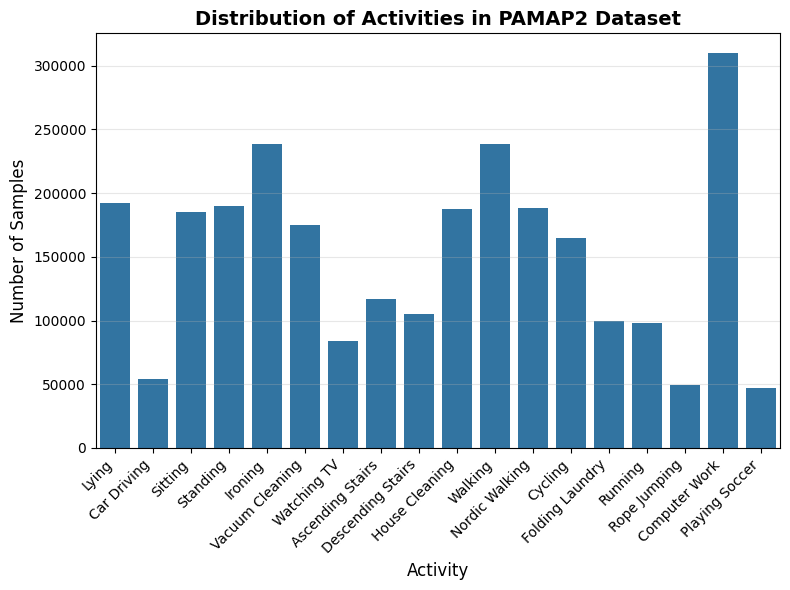

In [13]:
# ===== DATASET SUMMARY STATISTICS =====
print("Dataset Statistical Summary:")
print(df.describe())

print("\n" + "="*60)

# ===== ACTIVITY DISTRIBUTION =====
# Visualize class imbalance - important for understanding dataset composition
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='activity_name')
plt.xlabel('Activity', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Distribution of Activities in PAMAP2 Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
def plot_session(sensor):
    """
    Plot average sensor signal patterns for each activity.
    
    Shows how a specific sensor varies over time for each activity class.
    Useful for understanding characteristic patterns and inter-subject variability.
    
    Parameters:
    -----------
    sensor : str
        Column name of the sensor to plot (e.g., 'imu_ankle_accel_16_z')
    """
    plt.figure(figsize=(12, 8))

    # Iterate through all activities (20 activities total)
    for i, activity_id in enumerate(activities):
        
        # Get all samples for this activity
        all_recordings = df[df['activity_id'] == activity_id].copy()
        
        # Sort by timestamp to maintain temporal order
        all_recordings = all_recordings.sort_values('timestamp')
        
        # Create relative index (0, 1, 2, ...) within each subject
        # This aligns recordings of different lengths
        all_recordings['relative_idx'] = all_recordings.groupby('subject_id').cumcount()

        # Calculate mean signal value at each relative time point
        activity_avg = all_recordings.groupby('relative_idx')[sensor].mean()
        
        # Calculate standard deviation (for confidence intervals)
        activity_std = all_recordings.groupby('relative_idx')[sensor].std()

        # Create DataFrame with mean, std, and bounds
        result_df = pd.DataFrame({
            'relative_idx': activity_avg.index, 
            'avg_value': activity_avg, 
            'std_value': activity_std
        })

        # Calculate confidence interval bounds (mean ± std)
        result_df['upper'] = result_df['avg_value'] + result_df['std_value']
        result_df['lower'] = result_df['avg_value'] - result_df['std_value']

        # Create subplot for this activity (4 rows × 5 cols = 20 subplots)
        plt.subplot(4, 5, i + 1)
        
        # Plot mean signal
        plt.plot(result_df['relative_idx'], result_df['avg_value'], 
                color='blue', linewidth=2)
        
        # Add shaded confidence interval
        plt.fill_between(result_df['relative_idx'], 
                        result_df['lower'], 
                        result_df['upper'], 
                        alpha=0.2, color='blue')

        # Format subplot
        plt.xlabel('Relative Sample Index')
        plt.ylabel(f'{sensor}')
        plt.title(f"{activities[activity_id]}")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

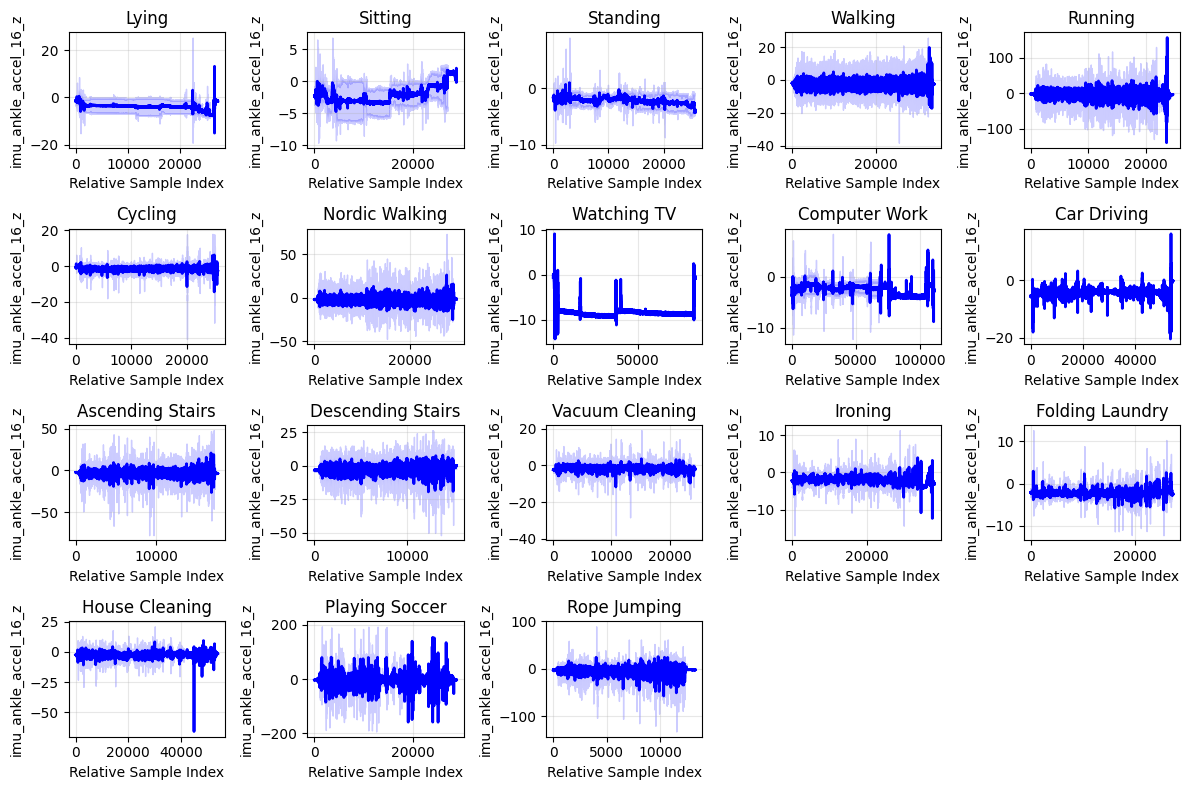

In [15]:
plot_session('imu_ankle_accel_16_z')

**COMPUTE 3D ACCELERATION & GYROSCOPE MAGNITUDES**  
Magnitude = sqrt(x² + y² + z²) Reduces 3-axis (x, y, z) sensor readings into a single scalar representing overall signal intensity, regardless of direction. Useful for activities where overall motion intensity matters more than direction (e.g. running, walking, jumping).


In [16]:
# ===== COMPUTE 3D ACCELERATION MAGNITUDE =====
def compute_accel_magnitude(df, prefix='16'):
    """Compute 3-axis acceleration magnitudes for hand/chest/ankle using 16-bit accel cols."""
    df['magnitude_hand_16'] = np.sqrt(df['imu_hand_accel_16_x']**2 + df['imu_hand_accel_16_y']**2 + df['imu_hand_accel_16_z']**2)
    df['magnitude_chest_16'] = np.sqrt(df['imu_chest_accel_16_x']**2 + df['imu_chest_accel_16_y']**2 + df['imu_chest_accel_16_z']**2)
    df['magnitude_ankle_16'] = np.sqrt(df['imu_ankle_accel_16_x']**2 + df['imu_ankle_accel_16_y']**2 + df['imu_ankle_accel_16_z']**2)
    return df


def compute_gyro_magnitude(df):
    """Compute 3-axis gyroscope magnitudes for hand/chest/ankle."""
    df['imu_hand_gyro_mag']  = np.sqrt(df['imu_hand_gyro_x']**2  + df['imu_hand_gyro_y']**2  + df['imu_hand_gyro_z']**2)
    df['imu_chest_gyro_mag'] = np.sqrt(df['imu_chest_gyro_x']**2 + df['imu_chest_gyro_y']**2 + df['imu_chest_gyro_z']**2)
    df['imu_ankle_gyro_mag'] = np.sqrt(df['imu_ankle_gyro_x']**2 + df['imu_ankle_gyro_y']**2 + df['imu_ankle_gyro_z']**2)
    return df

df = compute_accel_magnitude(df)
df = compute_gyro_magnitude(df)

## Step 5: Signal Processing & Feature Engineering

### 5.1: Compute Acceleration Magnitude
Calculate the 3D magnitude (Euclidean norm) of acceleration vectors for each sensor position.
This reduces 3-axis acceleration data to a single representative value.

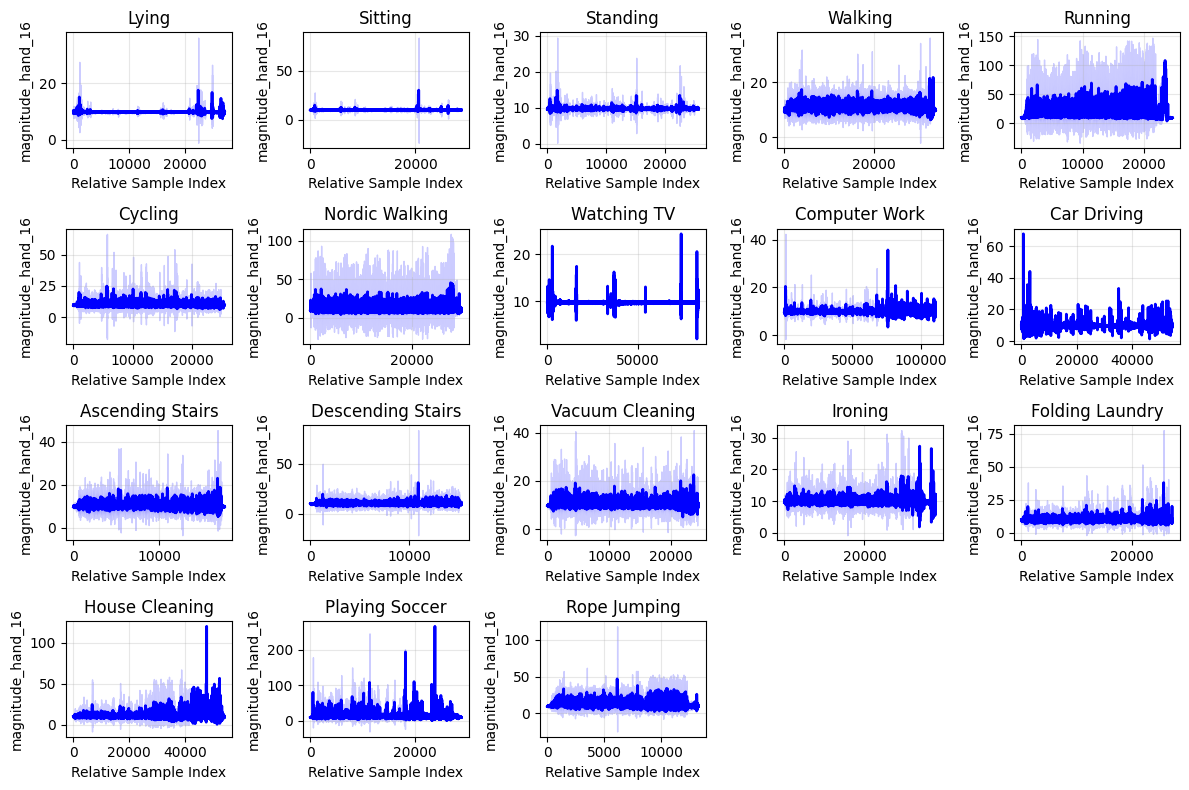

In [17]:
plot_session('magnitude_hand_16')

### 5.2: Filter Gravity Component from Acceleration

**Problem**: Accelerometers measure total acceleration = body motion + gravity (≈9.81 m/s² when still)

**Solution**: Use cascaded butterworth low-pass filters:
1. **High cutoff (20 Hz)**: Remove high-frequency noise → clean signal
2. **Low cutoff (0.3 Hz)**: Estimate gravity component (slowly varying)
3. **Subtract gravity from clean signal** → obtain body motion only

This preprocessing improves activity recognition by removing irrelevant DC offset and isolating true motion signals.

In [18]:
# ===== BUTTERWORTH LOW-PASS FILTER FUNCTION =====
def butter_lowpass_filter(data, cutoff, fs, order=4):
    """
    Apply a Butterworth low-pass filter to data.
    
    Parameters:
    -----------
    data : array-like
        Input signal to filter
    cutoff : float
        Cutoff frequency (Hz)
    fs : float
        Sampling frequency (Hz)
    order : int
        Filter order (default: 4). Higher = steeper roll-off
        
    Returns:
    --------
    filtered : ndarray
        Filtered signal (zero-phase using filtfilt)
    """
    # Normalize cutoff frequency to Nyquist frequency (fs/2)
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    
    # Design filter coefficients
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # Apply filter (filtfilt applies forward-backward for zero phase delay)
    return filtfilt(b, a, data)

def filter_signals_df(df, fs=100, cutoff_noise=20.0, cutoff_gravity=0.3, apply_noise=True, apply_gravity=True):
    """Apply low-pass filtering to remove noise and optionally remove gravity component.

    Parameters:
    - apply_noise: if True, apply high-cut filter (cutoff_noise) first
    - apply_gravity: if True, estimate gravity with low cutoff and subtract
    """
    for pos in ['hand', 'ankle', 'chest']:
        for axis in ['x', 'y', 'z']:
            col = f'imu_{pos}_accel_16_{axis}'
            raw = df[col].values
            clean = butter_lowpass_filter(raw, cutoff_noise, fs) if apply_noise else raw
            gravity = butter_lowpass_filter(clean, cutoff_gravity, fs) if apply_gravity else np.zeros_like(clean)
            body = clean - gravity
            df[f'{col}_filtered'] = body

        # compute magnitude of filtered body acc for this position
        df[f'magnitude_{pos}_filtered'] = np.sqrt(
            df[f'imu_{pos}_accel_16_x_filtered']**2 +
            df[f'imu_{pos}_accel_16_y_filtered']**2 +
            df[f'imu_{pos}_accel_16_z_filtered']**2
        )
    return df

# ===== FILTER PARAMETERS =====
fs = 100                # Sampling rate: 100 Hz (PAMAP2 specification)
cutoff_noise = 20.0     # High-pass threshold: remove frequencies above 20 Hz
cutoff_gravity = 0.3    # Low-pass threshold: capture slow gravity component (≈0.1-0.5 Hz)

df = filter_signals_df(df, fs=fs, cutoff_noise=cutoff_noise, cutoff_gravity=cutoff_gravity)


### Visualization: Raw vs Filtered Signal
Compare raw acceleration magnitude with filtered (gravity-removed) version to visualize the impact of preprocessing.

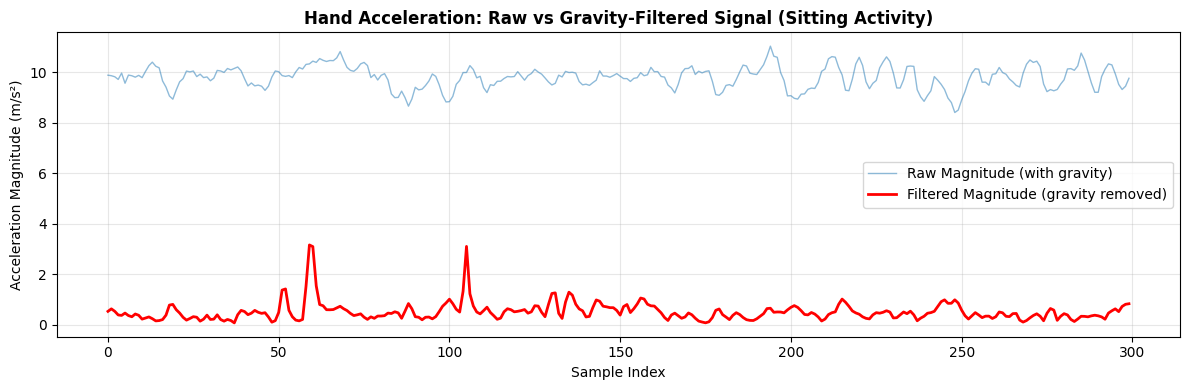

In [19]:
# Select a sample from "Sitting" activity for demonstration
df_sample = df[df['activity_name'] == 'Sitting'].head(300)

# Create comparison plot
plt.figure(figsize=(12, 4))

# Plot raw magnitude (includes gravity)
plt.plot(df_sample['magnitude_hand_16'].values, 
         label='Raw Magnitude (with gravity)', 
         alpha=0.5, linewidth=1)

# Plot filtered magnitude (gravity removed)
plt.plot(df_sample['magnitude_hand_filtered'].values, 
         label='Filtered Magnitude (gravity removed)', 
         linewidth=2, color='red')

plt.title('Hand Acceleration: Raw vs Gravity-Filtered Signal (Sitting Activity)', 
          fontsize=12, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Acceleration Magnitude (m/s²)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
df.head()

,timestamp,activity_id,imu_hand_temperature,imu_hand_accel_16_x,imu_hand_accel_16_y,imu_hand_accel_16_z,imu_hand_gyro_x,imu_hand_gyro_y,imu_hand_gyro_z,imu_chest_temperature,...,imu_hand_accel_16_z_filtered,magnitude_hand_filtered,imu_ankle_accel_16_x_filtered,imu_ankle_accel_16_y_filtered,imu_ankle_accel_16_z_filtered,magnitude_ankle_filtered,imu_chest_accel_16_x_filtered,imu_chest_accel_16_y_filtered,imu_chest_accel_16_z_filtered,magnitude_chest_filtered
2928,37.66,1,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,32.1875,...,-0.508192,0.579830,-0.010406,0.013001,0.014605,0.022150,-0.152147,0.010958,0.044639,0.158939
2929,37.67,1,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,32.1875,...,-0.399361,0.572561,-0.043690,-0.016244,-0.057842,0.074286,-0.078862,0.043989,-0.030616,0.095350
2930,37.68,1,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,32.1875,...,-0.273342,0.855986,-0.052597,-0.029195,-0.070212,0.092459,-0.022816,0.070328,-0.073086,0.103962
2931,37.69,1,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,32.1875,...,-0.145778,0.952111,-0.043219,-0.026986,-0.047339,0.069549,0.007602,0.077467,-0.078860,0.110806
2932,37.70,1,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,32.1875,...,-0.073198,0.848379,-0.042259,-0.020211,-0.055898,0.072930,0.016384,0.059872,-0.067647,0.091811


## Step 6: Window Segmentation & Feature Extraction

### 6.1: Create Sliding Windows

The raw continuous time-series data must be segmented into fixed-size windows for feature extraction.

**Parameters**:
- **Window size**: 200 samples = 2 seconds @ 100 Hz sampling rate
- **Step size**: 100 samples = 50% overlap between windows
- **Grouping**: Windows are created separately for each (subject_id, activity_id) pair to ensure:
  - No windows span multiple activities
  - No windows span multiple subjects (important for subject-independent evaluation)

In [21]:
def sliding_window(df, window_size, step, group_cols=['subject_id', 'activity_id'], time_col='timestamp'):
    """
    Create sliding windows from time-series data.
    
    Windows are created within each group (subject + activity) to prevent:
    - Cross-activity contamination
    - Cross-subject contamination
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with time-series data
    window_size : int
        Number of samples per window
    step : int
        Number of samples to slide window (stride)
        - step = window_size → non-overlapping windows
        - step < window_size → overlapping windows
    group_cols : list
        Columns to group by (create separate windows per group)
    time_col : str
        Column to sort by within each group
        
    Returns:
    --------
    pd.DataFrame
        Data with 'window_id' column added, ready for per-window feature extraction
    """
    
    # Sort data by group and timestamp
    sort_cols = group_cols + ([time_col] if time_col in df.columns else [])
    df = df.sort_values(sort_cols).reset_index(drop=True)

    windows = []  # List to store indices for each window
    window_id = 0

    # Create windows for each (subject, activity) group
    for _, group in df.groupby(group_cols, sort=False):
        # Get indices for this group's data
        idx = group.index.to_numpy()
        n = len(group)

        # Slide window across group data with specified step
        for start in range(0, n - window_size + 1, step):
            # Collect indices for this window
            windows.append(idx[start : start + window_size])
            window_id += 1

    # Handle case where no valid windows could be created
    if not windows:
        print("Warning: No valid windows created. Check window_size vs. data length.")
        return pd.DataFrame()

    # Concatenate all window indices
    all_idx = np.concatenate(windows)
    
    # Create result dataframe with only windowed data
    result = df.loc[all_idx].reset_index(drop=True)

    # Assign window IDs: each sample gets the ID of its window
    result["window_id"] = np.repeat(np.arange(len(windows)), window_size)

    return result

### 6.3: Extract Statistical & Spectral Features

For each window, compute 50+ features per sensor channel:

**Time-Domain Features**:
- Mean, Std, Min, Max, Range, Median, IQR, RMS, Energy, MAD (Mean Absolute Deviation), Zero Crossings

**Frequency-Domain Features**:
- FFT: Mean, Std, Energy, Dominant Frequency, Spectral Entropy

**Result**: Each window (24 sensor channels) → ~600 features → Feature matrix for ML model training

In [22]:
def extract_features(window: np.ndarray, feature_cols: list, verbose=False, i=None) -> dict:
    """
    Extract 50+ statistical and spectral features from a single time-series window.
    
    This function computes both time-domain and frequency-domain features that
    capture signal characteristics useful for activity recognition.
    
    Parameters:
    -----------
    window : np.ndarray
        2D array of shape (window_size, n_features) containing sensor data
    feature_cols : list
        Names of sensor columns (for feature naming)
    verbose : bool
        Print progress every 1000 windows
    i : int
        Current window index (for progress tracking)
        
    Returns:
    --------
    dict
        Dictionary with feature names as keys and computed values as values
    """
    
    if verbose and i is not None and i % 1000 == 0:
        print(f"[extract] Processing window {i}")

    feats = {}

    for i_col, col in enumerate(feature_cols):
        x = window[:, i_col]

        feats[f'{col}_mean']   = np.mean(x)
        feats[f'{col}_std']    = np.std(x)
        feats[f'{col}_min']    = np.min(x)
        feats[f'{col}_max']    = np.max(x)
        feats[f'{col}_range']  = np.max(x) - np.min(x)
        feats[f'{col}_median'] = np.median(x)
        feats[f'{col}_iqr']    = stats.iqr(x)
        feats[f'{col}_rms']    = np.sqrt(np.mean(x**2))
        feats[f'{col}_energy'] = np.mean(x**2)
        feats[f'{col}_mad']    = np.mean(np.abs(x - np.mean(x)))
        feats[f'{col}_zc']     = np.sum(np.diff(np.sign(x)) != 0)

        fft_vals = np.abs(np.fft.rfft(x))
        freqs = np.fft.rfftfreq(len(x), d=1/100)

        feats[f'{col}_fft_mean']      = np.mean(fft_vals)
        feats[f'{col}_fft_std']       = np.std(fft_vals)
        feats[f'{col}_fft_energy']    = np.mean(fft_vals**2)

        if len(fft_vals) > 1:
            peak_idx = np.argmax(fft_vals[1:]) + 1
            feats[f'{col}_dominant_freq'] = freqs[peak_idx]
        else:
            feats[f'{col}_dominant_freq'] = 0.0

        p = fft_vals / (np.sum(fft_vals) + 1e-10)
        feats[f'{col}_spectral_entropy'] = stats.entropy(p + 1e-10)

    return feats


def build_feature_matrix(df_windowed, feature_cols, meta_cols=None, verbose=True):
    """
    Build feature matrix by extracting features from all windows.
    
    Parameters:
    -----------
    df_windowed : pd.DataFrame
        Dataframe with 'window_id' column and sensor data
    feature_cols : list
        Column names to extract features from
    meta_cols : list
        Metadata columns to exclude from feature extraction
    verbose : bool
        Print progress information
        
    Returns:
    --------
    pd.DataFrame
        Feature matrix with one row per window
    """
    
    if meta_cols is None:
        meta_cols = ['subject_id', 'activity_id', 'timestamp', 'window_id']

    n_windows  = df_windowed['window_id'].nunique()
    n_features = len(feature_cols)

    print("\n" + "="*60)
    print("FEATURE EXTRACTION CONFIGURATION")
    print("="*60)
    print(f"Number of windows    : {n_windows:,}")
    print(f"Features per window  : {n_features}")
    print(f"Est. features/window : ~{n_features * 16}  (time-domain + freq)")
    print(f"Verbose progress     : {'Yes' if verbose else 'No'}\n")

    X_raw = df_windowed[feature_cols].to_numpy().reshape(n_windows, -1, n_features)

    y = (
        df_windowed
        .groupby('window_id')['activity_id']
        .agg(lambda x: x.mode()[0])
        .to_numpy()
    )

    subjects = (
        df_windowed
        .groupby('window_id')['subject_id']
        .first()
        .to_numpy()
    )

    rows = []

    for i in range(n_windows):
        if verbose and i % 500 == 0:
            print(f"[progress] Processing window {i:,}/{n_windows:,}")

        feats = extract_features(X_raw[i], feature_cols, verbose=verbose, i=i)
        feats['label'] = y[i]
        feats['subject_id'] = subjects[i]
        rows.append(feats)

    df_features = pd.DataFrame(rows)

    print("\n" + "="*60)
    print("FEATURE EXTRACTION COMPLETE")
    print("="*60)
    print(f"Feature matrix shape : {df_features.shape}")
    print(f"Memory usage         : {df_features.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print(f"Samples (windows)    : {df_features.shape[0]:,}")
    print(f"Total features       : {df_features.shape[1]:,}")

    return df_features


def make_windows_and_features(df, window_size=200, step=100, meta_cols=None, verbose=True):
    """Segment df into windows and extract features returning df_windowed and df_features."""
    if meta_cols is None:
        meta_cols = ['subject_id', 'activity_id', 'timestamp', 'window_id', 'activity_name']

    df_windowed = sliding_window(df, window_size=window_size, step=step)
    if df_windowed.empty:
        return df_windowed, pd.DataFrame()

    feature_cols = [c for c in df_windowed.columns if c not in meta_cols]
    df_features = build_feature_matrix(df_windowed, feature_cols, verbose=verbose)
    return df_windowed, df_features

window_size = 512 # 100 Hz : 100 samples/s => 512 samples : 5s of data + puissance de 2
step = 256 # 50% overlapping


df_windowed, df_features = make_windows_and_features(df, window_size=window_size, step=step, verbose=True)


FEATURE EXTRACTION CONFIGURATION
Number of windows    : 10,489
Features per window  : 43
Est. features/window : ~688  (time-domain + freq)
Verbose progress     : Yes

[progress] Processing window 0/10,489
[extract] Processing window 0
[progress] Processing window 500/10,489
[progress] Processing window 1,000/10,489
[extract] Processing window 1000
[progress] Processing window 1,500/10,489
[progress] Processing window 2,000/10,489
[extract] Processing window 2000
[progress] Processing window 2,500/10,489
[progress] Processing window 3,000/10,489
[extract] Processing window 3000
[progress] Processing window 3,500/10,489
[progress] Processing window 4,000/10,489
[extract] Processing window 4000
[progress] Processing window 4,500/10,489
[progress] Processing window 5,000/10,489
[extract] Processing window 5000
[progress] Processing window 5,500/10,489
[progress] Processing window 6,000/10,489
[extract] Processing window 6000
[progress] Processing window 6,500/10,489
[progress] Processing 

In [23]:
df_windowed.head()

,timestamp,activity_id,imu_hand_temperature,imu_hand_accel_16_x,imu_hand_accel_16_y,imu_hand_accel_16_z,imu_hand_gyro_x,imu_hand_gyro_y,imu_hand_gyro_z,imu_chest_temperature,...,magnitude_hand_filtered,imu_ankle_accel_16_x_filtered,imu_ankle_accel_16_y_filtered,imu_ankle_accel_16_z_filtered,magnitude_ankle_filtered,imu_chest_accel_16_x_filtered,imu_chest_accel_16_y_filtered,imu_chest_accel_16_z_filtered,magnitude_chest_filtered,window_id
0,37.66,1,30.375,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145,32.1875,...,0.579830,-0.010406,0.013001,0.014605,0.022150,-0.152147,0.010958,0.044639,0.158939,0
1,37.67,1,30.375,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538,32.1875,...,0.572561,-0.043690,-0.016244,-0.057842,0.074286,-0.078862,0.043989,-0.030616,0.095350,0
2,37.68,1,30.375,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831,32.1875,...,0.855986,-0.052597,-0.029195,-0.070212,0.092459,-0.022816,0.070328,-0.073086,0.103962,0
3,37.69,1,30.375,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374,32.1875,...,0.952111,-0.043219,-0.026986,-0.047339,0.069549,0.007602,0.077467,-0.078860,0.110806,0
4,37.70,1,30.375,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582,32.1875,...,0.848379,-0.042259,-0.020211,-0.055898,0.072930,0.016384,0.059872,-0.067647,0.091811,0


In [51]:
# ===== WINDOWED DATASET STATISTICS =====
print("Windowed dataset statistics:")
print(f"  Total samples (rows): {df_windowed.shape[0]:,}")
print(f"  Unique windows:       {df_windowed['window_id'].nunique():,}")
print(f"  Total columns:        {df_windowed.shape[1]}")
print(f"  Samples per window:   {window_size}")
print(f"  RAM used:             {df_windowed.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Windowed dataset statistics:
  Total samples (rows): 5,370,368
  Unique windows:       10,489
  Total columns:        48
  Samples per window:   512
  RAM used:             2.38 GB


In [52]:
df_features.to_csv('features2.csv')

## Step 7: Model Training & Evaluation

### 7.1: 2D Visualization with t-SNE

In [26]:
X = df_features.drop(columns=['label', 'subject_id'])
y = df_features['label']
groups = df_features['subject_id'].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_jobs=-1) # visualisation 2D
X_tsne = tsne.fit_transform(X_scaled)


tsne_df = pd.DataFrame({
     'x': X_tsne[:, 0],
     'y': X_tsne[:, 1],
     'activity': y.values
})

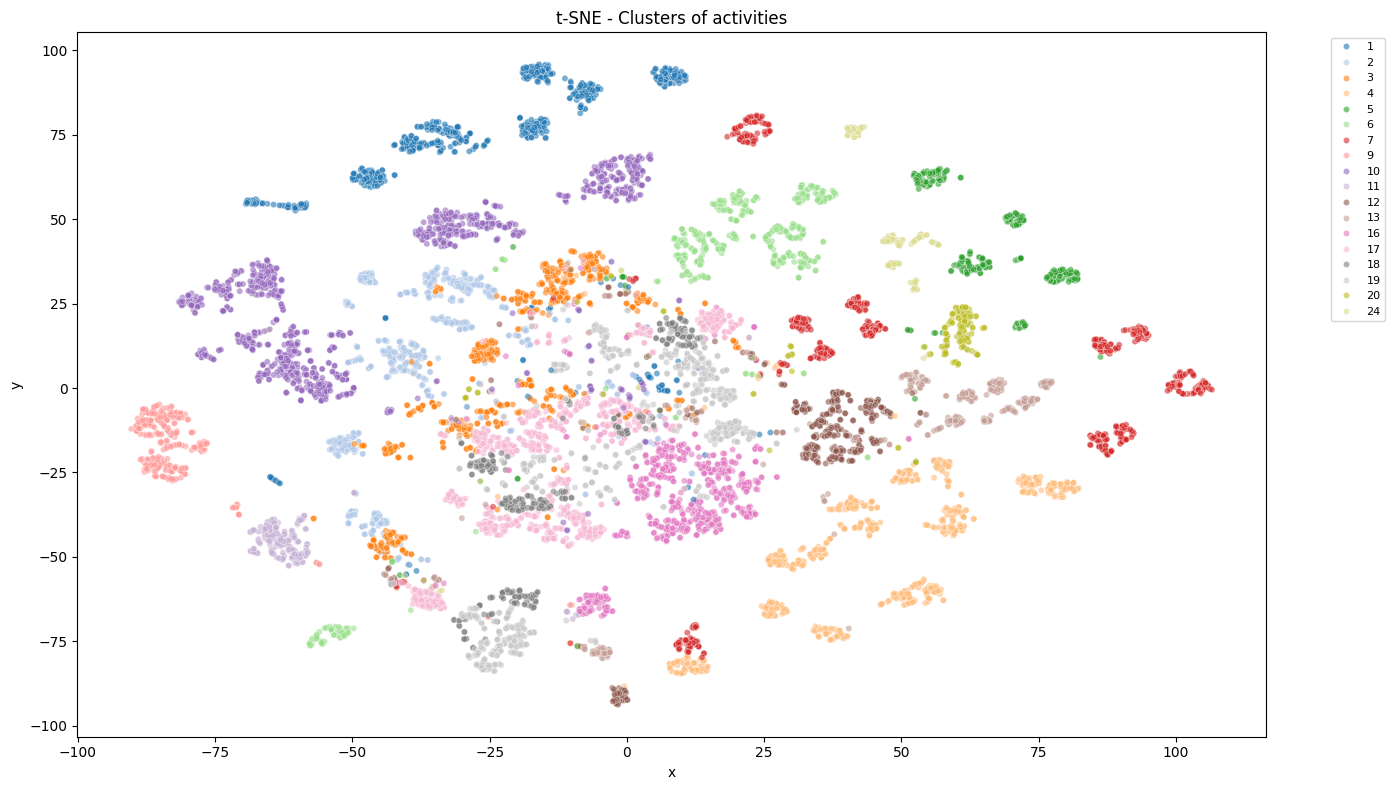

In [27]:
plt.figure(figsize=(14, 8))
sns.scatterplot(
     data=tsne_df,
     x='x', y='y',
     hue='activity',
     palette='tab20',
     alpha=0.6,
     s=20
)
plt.title('t-SNE - Clusters of activities')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 7.3: Execute Training & Evaluation

Run the LOGO cross-validation pipeline. This will train and evaluate all three classifiers.

In [28]:
# ===== HYPERPARAMETER GRIDS FOR EACH CLASSIFIER =====

# Logistic Regression hyperparameters
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],           # Inverse regularization strength
    'solver': ['lbfgs'],                # Algorithm
    'max_iter': [5000],                 # Max iterations
    'class_weight': ['balanced']        # Handle class imbalance
}

# Support Vector Machine hyperparameters
param_grid_svm = {
    'C': [1, 10, 100],                 # Regularization parameter
    'gamma': [0.001, 0.01, 0.1],       # Kernel coefficient (RBF)
    'kernel': ['rbf'],                 # RBF kernel (non-linear)
    'class_weight': ['balanced']       # Handle class imbalance
}

# Random Forest hyperparameters
param_grid_rf = {
    'n_estimators': [200],             # Number of trees
    'max_features': ['sqrt'],          # Features per split
    'max_depth': [None],               # Tree depth (None = no limit)
    'class_weight': ['balanced']       # Handle class imbalance
}

MODEL_REGISTRY = {
    'lr':  (LogisticRegression(max_iter=5000), param_grid_lr, True),
    'svm': (SVC(), param_grid_svm, True),
    'rf':  (RandomForestClassifier(n_jobs=-1), param_grid_rf, False),
}

def train_and_classify(X, y, groups, model='rf'):
    """
    Train a siingle clf using Leave-One-Group-Out cross-validation.
    
    Parameters:
    -----------
    X : np.ndarray
        Feature matrix (n_samples, n_features)
    y : np.ndarray
        Target labels (n_samples,)
    groups : np.ndarray
        Group labels for LOGO (subject IDs) (n_samples,)
    model : str
        Which model to train: 'lr', 'svm', or 'rf'. Only this model is
        trained/tuned/evaluated — call the function again with a different
        `model` value to run another one.
        
    Returns:
    --------
    tuple
        (report, best_params)
        report : classification_report dict
        best_params : list of best hyperparameters found (one per fold)
    """
    
    if model not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model '{model}'. Choose from {list(MODEL_REGISTRY.keys())}")

    estimator, param_grid, needs_scaling = MODEL_REGISTRY[model]
    
    # Initialize Leave-One-Group-Out cross-validation splitter
    logo = LeaveOneGroupOut()
    n_groups = logo.get_n_splits(X, y, groups=groups)

    # Initialize prediction storage
    predictions, true_labels = [], []
    best_params = []

    print(f"\nStarting Leave-One-Group-Out (LOGO) Cross-Validation")
    print(f"Model: {model.upper()}")
    print(f"Number of folds (subjects): {n_groups}\n")

    # Iterate through each fold
    for fold_num, (train_idx, test_idx) in enumerate(tqdm(logo.split(X, y, groups=groups), 
                                                           total=n_groups,
                                                           desc="LOGO Folds")):
        # Split data for this fold
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # ===== STANDARDIZATION (only if needed for this model) =====
        if needs_scaling:
            scaler = StandardScaler()
            X_train_fold = scaler.fit_transform(X_train)
            X_test_fold = scaler.transform(X_test)
        else:
            X_train_fold = X_train
            X_test_fold = X_test

        # ===== INNER CROSS-VALIDATION FOR HYPERPARAMETER TUNING =====
        # Use stratified 3-fold CV within training set
        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        print(f"  Fold {fold_num + 1}/{n_groups}: Training {model.upper()}...")
        
        gs = GridSearchCV(
            estimator,
            param_grid,
            cv=inner_cv,
            scoring='f1_macro',
            n_jobs=-1
        )
        gs.fit(X_train_fold, y_train)
        best_params.append(gs.best_params_)
        predictions.extend(gs.best_estimator_.predict(X_test_fold))

        # Collect true labels for this fold
        true_labels.extend(y_test)

    # ===== GENERATE CLASSIFICATION REPORT =====
    print("\n" + "="*70)
    print(f"CLASSIFICATION RESULTS (LOGO Cross-Validation) — {model.upper()}")
    print("="*70)

    print(classification_report(true_labels, predictions,
                              target_names=[activities[a] for a in activities]))

    return (
        classification_report(true_labels, predictions, output_dict=True),
        best_params
    )

In [29]:
from sklearn.model_selection import (
    LeaveOneGroupOut,
    GroupKFold,
    StratifiedGroupKFold,
    LeavePGroupsOut,
    GroupShuffleSplit,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


def get_splitter(strategy='logo', n_splits=5, p=2, test_size=0.2, random_state=42):
    """
    Factory for subject-aware splitters.

    strategy options:
    ------------------
    'logo'    : LeaveOneGroupOut          -> n_folds = n_subjects (your original)
    'gkf'     : GroupKFold                -> n_folds = n_splits, faster than LOGO
    'sgkf'    : StratifiedGroupKFold      -> n_folds = n_splits, balances classes per fold
    'lpgo'    : LeavePGroupsOut           -> leaves p subjects out per fold
    'holdout' : GroupShuffleSplit(1 split)-> single train/test split by subject, fastest
    """
    if strategy == 'logo':
        return LeaveOneGroupOut()
    elif strategy == 'gkf':
        return GroupKFold(n_splits=n_splits)
    elif strategy == 'sgkf':
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    elif strategy == 'lpgo':
        return LeavePGroupsOut(n_groups=p)
    elif strategy == 'holdout':
        return GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    else:
        raise ValueError(f"Unknown strategy '{strategy}'. Choose from "
                          "'logo', 'gkf', 'sgkf', 'lpgo', 'holdout'.")


def train_and_classify_flex(X, y, groups, model='rf', MODEL_REGISTRY=None,
                             split_strategy='gkf', n_splits=5, p=2,
                             test_size=0.2, activities=None):
    """
    Same role as your original train_and_classify, but the outer
    cross-validation scheme is swappable via `split_strategy`.

    Parameters
    ----------
    split_strategy : str
        One of 'logo', 'gkf', 'sgkf', 'lpgo', 'holdout' (see get_splitter).
    n_splits : int
        Number of folds for 'gkf' / 'sgkf'.
    p : int
        Number of groups left out per fold for 'lpgo'.
    test_size : float
        Fraction of subjects held out for 'holdout'.
    activities : dict
        Optional activity_id -> name map, used only for the printed report.
    """
    if MODEL_REGISTRY is None:
        raise ValueError("Pass your MODEL_REGISTRY dict (model -> (estimator, param_grid, needs_scaling)).")

    estimator, param_grid, needs_scaling = MODEL_REGISTRY[model]

    splitter = get_splitter(split_strategy, n_splits=n_splits, p=p, test_size=test_size)

    # StratifiedGroupKFold/GroupKFold/LeavePGroupsOut/GroupShuffleSplit all
    # accept (X, y, groups); LOGO does too. Some need y for stratification.
    try:
        n_groups_total = splitter.get_n_splits(X, y, groups=groups)
    except TypeError:
        n_groups_total = splitter.get_n_splits(groups=groups)

    predictions, true_labels = [], []
    best_params = []

    print(f"\nStarting {split_strategy.upper()} Cross-Validation")
    print(f"Model: {model.upper()}")
    print(f"Number of folds: {n_groups_total}\n")

    for fold_num, (train_idx, test_idx) in enumerate(
        tqdm(splitter.split(X, y, groups=groups), total=n_groups_total, desc=f"{split_strategy.upper()} Folds")
    ):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if needs_scaling:
            scaler = StandardScaler()
            X_train_fold = scaler.fit_transform(X_train)
            X_test_fold = scaler.transform(X_test)
        else:
            X_train_fold = X_train
            X_test_fold = X_test

        print(f" Fold {fold_num + 1}/{n_groups_total}: Training {model.upper()}...")

        inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        gs = GridSearchCV(estimator, param_grid, cv=inner_cv, scoring='f1_macro', n_jobs=-1)
        gs.fit(X_train_fold, y_train)

        best_params.append(gs.best_params_)
        predictions.extend(gs.best_estimator_.predict(X_test_fold))
        true_labels.extend(y_test)

    print("\n" + "=" * 70)
    print(f"CLASSIFICATION RESULTS ({split_strategy.upper()} CV) — {model.upper()}")
    print("=" * 70)

    target_names = None
    if activities is not None:
        present_labels = sorted(set(true_labels) | set(predictions))
        target_names = [activities.get(a, str(a)) for a in present_labels]

    print(classification_report(true_labels, predictions, target_names=target_names, zero_division=0))

    return (
        classification_report(true_labels, predictions, output_dict=True, zero_division=0),
        best_params,
    )

**Random Forest**

In [30]:
groups = df_features['subject_id'].to_numpy()
X_np = X.to_numpy()
y_np = y.to_numpy()

        
# Fast iteration: 5-fold GroupKFold instead of LOGO (9 folds -> 5, ~half the time)
rf_report_groupKFold, rf_params_groupKFold = train_and_classify_flex(
    X_np, y_np, groups, model='rf', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='gkf', n_splits=5, activities=activities
)


Starting GKF Cross-Validation
Model: RF
Number of folds: 5



GKF Folds:   0%|          | 0/5 [00:00<?, ?it/s]

 Fold 1/5: Training RF...


GKF Folds:  20%|██        | 1/5 [00:09<00:37,  9.49s/it]

 Fold 2/5: Training RF...


...

 Fold 4/5: Training RF...


GKF Folds:  80%|████████  | 4/5 [00:36<00:08,  8.80s/it]

 Fold 5/5: Training RF...


GKF Folds: 100%|██████████| 5/5 [00:44<00:00,  8.99s/it]


CLASSIFICATION RESULTS (GKF CV) — RF
                   precision    recall  f1-score   support

            Lying       0.66      0.95      0.78       742
          Sitting       0.46      0.66      0.54       711
         Standing       0.68      0.71      0.69       730
          Walking       0.93      0.97      0.95       921
          Running       0.78      0.85      0.81       376
          Cycling       0.98      0.95      0.96       634
   Nordic Walking       0.99      0.91      0.95       725
      Watching TV       0.00      0.00      0.00       325
    Computer Work       0.80      0.65      0.72      1205
      Car Driving       0.00      0.00      0.00       211
 Ascending Stairs       0.84      0.90      0.87       445
Descending Stairs       0.86      0.81      0.83       398
  Vacuum Cleaning       0.57      0.78      0.66       673
          Ironing       0.49      0.68      0.57       921
  Folding Laundry       0.00      0.00      0.00       384
   House Cleaning

In [31]:
print(rf_params_groupKFold)

[{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}]


In [32]:
# Class-balance-aware version (helps your zero-recall classes like Watching TV, Car Driving)
rf_report_StratifiedGroupKFold, rf_params_StratifiedGroupKFold = train_and_classify_flex(
    X_np, y_np, groups, model='rf', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='sgkf', n_splits=5, activities=activities
)


Starting SGKF Cross-Validation
Model: RF
Number of folds: 5



SGKF Folds:   0%|          | 0/5 [00:00<?, ?it/s]

 Fold 1/5: Training RF...


SGKF Folds:  20%|██        | 1/5 [00:08<00:32,  8.13s/it]

 Fold 2/5: Training RF...


...

 Fold 4/5: Training RF...


SGKF Folds:  80%|████████  | 4/5 [00:31<00:07,  7.97s/it]

 Fold 5/5: Training RF...


SGKF Folds: 100%|██████████| 5/5 [00:39<00:00,  7.92s/it]


CLASSIFICATION RESULTS (SGKF CV) — RF
                   precision    recall  f1-score   support

            Lying       0.66      0.96      0.78       742
          Sitting       0.40      0.57      0.47       711
         Standing       0.73      0.72      0.72       730
          Walking       0.92      0.97      0.95       921
          Running       0.87      0.85      0.86       376
          Cycling       0.98      0.94      0.96       634
   Nordic Walking       0.99      0.88      0.93       725
      Watching TV       0.00      0.00      0.00       325
    Computer Work       0.72      0.60      0.65      1205
      Car Driving       0.00      0.00      0.00       211
 Ascending Stairs       0.91      0.91      0.91       445
Descending Stairs       0.87      0.85      0.86       398
  Vacuum Cleaning       0.52      0.51      0.52       673
          Ironing       0.49      0.66      0.56       921
  Folding Laundry       0.00      0.00      0.00       384
   House Cleanin

In [33]:
print(rf_params_StratifiedGroupKFold)

[{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}]


In [34]:
# Quick single holdout split (good for fast prototyping before a full run)
rf_report_holdout, rf_params_holdout = train_and_classify_flex(
    X_np, y_np, groups, model='rf', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='holdout', test_size=0.2, activities=activities
)



Starting HOLDOUT Cross-Validation
Model: RF
Number of folds: 1



HOLDOUT Folds:   0%|          | 0/1 [00:00<?, ?it/s]

 Fold 1/1: Training RF...


HOLDOUT Folds: 100%|██████████| 1/1 [00:07<00:00,  7.41s/it]


CLASSIFICATION RESULTS (HOLDOUT CV) — RF
                   precision    recall  f1-score   support

            Lying       0.98      0.96      0.97       183
          Sitting       0.35      0.80      0.49       174
         Standing       0.36      0.42      0.39       195
          Walking       0.82      0.98      0.89       248
          Running       0.77      0.70      0.73        98
          Cycling       0.99      0.96      0.98       195
   Nordic Walking       1.00      0.76      0.86       226
    Computer Work       0.62      0.04      0.07       267
 Ascending Stairs       0.88      0.95      0.91       110
Descending Stairs       0.75      0.91      0.82        94
  Vacuum Cleaning       0.82      0.98      0.89       172
          Ironing       0.57      0.79      0.67       238
  Folding Laundry       0.00      0.00      0.00        91
   House Cleaning       0.59      0.61      0.60       161
   Playing Soccer       0.04      0.01      0.02        69
     Rope Jum

In [35]:
print(rf_params_holdout)

[{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}]


In [36]:
# Leave-2-subjects-out
rf_report_LeavePGroupsOut, rf_params_LeavePGroupsOut = train_and_classify_flex(
    X_np, y_np, groups, model='rf', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='lpgo', p=2, activities=activities
)


Starting LPGO Cross-Validation
Model: RF
Number of folds: 36



LPGO Folds:   0%|          | 0/36 [00:00<?, ?it/s]

 Fold 1/36: Training RF...


LPGO Folds:   3%|▎         | 1/36 [00:07<04:08,  7.11s/it]

 Fold 2/36: Training RF...


...

 Fold 35/36: Training RF...


LPGO Folds:  97%|█████████▋| 35/36 [04:27<00:08,  8.12s/it]

 Fold 36/36: Training RF...


LPGO Folds: 100%|██████████| 36/36 [04:35<00:00,  7.67s/it]


CLASSIFICATION RESULTS (LPGO CV) — RF
                   precision    recall  f1-score   support

            Lying       0.66      0.95      0.78      5936
          Sitting       0.37      0.61      0.46      5688
         Standing       0.68      0.72      0.70      5840
          Walking       0.91      0.97      0.94      7368
          Running       0.84      0.86      0.85      3008
          Cycling       0.97      0.94      0.96      5072
   Nordic Walking       0.98      0.89      0.93      5800
      Watching TV       0.00      0.00      0.00      2600
    Computer Work       0.70      0.47      0.57      9640
      Car Driving       0.00      0.00      0.00      1688
 Ascending Stairs       0.89      0.90      0.89      3560
Descending Stairs       0.89      0.84      0.86      3184
  Vacuum Cleaning       0.56      0.76      0.65      5384
          Ironing       0.49      0.67      0.57      7368
  Folding Laundry       0.00      0.00      0.00      3072
   House Cleanin

In [37]:
print(rf_params_LeavePGroupsOut)

[{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_featur

In [38]:
rf_report_LeaveOneGroupOut, rf_params_LeaveOneGroupOut = train_and_classify_flex(
    X_np, y_np, groups, model='rf', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='logo', activities=activities
)


Starting LOGO Cross-Validation
Model: RF
Number of folds: 9



LOGO Folds:   0%|          | 0/9 [00:00<?, ?it/s]

 Fold 1/9: Training RF...


LOGO Folds:  11%|█         | 1/9 [00:07<01:01,  7.69s/it]

 Fold 2/9: Training RF...


...

 Fold 8/9: Training RF...


LOGO Folds:  89%|████████▉ | 8/9 [01:10<00:08,  8.87s/it]

 Fold 9/9: Training RF...


LOGO Folds: 100%|██████████| 9/9 [01:21<00:00,  9.02s/it]


CLASSIFICATION RESULTS (LOGO CV) — RF
                   precision    recall  f1-score   support

            Lying       0.67      0.95      0.79       742
          Sitting       0.36      0.63      0.46       711
         Standing       0.75      0.72      0.73       730
          Walking       0.91      0.96      0.94       921
          Running       0.82      0.85      0.83       376
          Cycling       0.98      0.94      0.96       634
   Nordic Walking       0.98      0.89      0.93       725
      Watching TV       0.00      0.00      0.00       325
    Computer Work       0.72      0.51      0.60      1205
      Car Driving       0.00      0.00      0.00       211
 Ascending Stairs       0.91      0.91      0.91       445
Descending Stairs       0.90      0.84      0.87       398
  Vacuum Cleaning       0.56      0.79      0.66       673
          Ironing       0.51      0.71      0.59       921
  Folding Laundry       0.00      0.00      0.00       384
   House Cleanin

In [39]:
print(rf_params_LeaveOneGroupOut)

[{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}]


**Logistic Regression**

In [40]:
# Fast iteration: 5-fold GroupKFold
lr_report_groupKFold, lr_params_groupKFold = train_and_classify_flex(
    X_np, y_np, groups, model='lr', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='gkf', n_splits=5, activities=activities
)
print(lr_params_groupKFold)


Starting GKF Cross-Validation
Model: LR
Number of folds: 5



GKF Folds:   0%|          | 0/5 [00:00<?, ?it/s]

 Fold 1/5: Training LR...


GKF Folds:  20%|██        | 1/5 [00:07<00:30,  7.74s/it]

 Fold 2/5: Training LR...


...

 Fold 4/5: Training LR...


GKF Folds:  80%|████████  | 4/5 [00:29<00:07,  7.62s/it]

 Fold 5/5: Training LR...


GKF Folds: 100%|██████████| 5/5 [00:38<00:00,  7.66s/it]


CLASSIFICATION RESULTS (GKF CV) — LR
                   precision    recall  f1-score   support

            Lying       0.71      0.86      0.78       742
          Sitting       0.48      0.61      0.54       711
         Standing       0.77      0.62      0.68       730
          Walking       0.97      0.90      0.93       921
          Running       0.57      0.78      0.66       376
          Cycling       0.97      0.94      0.96       634
   Nordic Walking       0.99      0.90      0.94       725
      Watching TV       0.00      0.00      0.00       325
    Computer Work       0.79      0.53      0.64      1205
      Car Driving       0.00      0.00      0.00       211
 Ascending Stairs       0.84      0.90      0.87       445
Descending Stairs       0.73      0.86      0.79       398
  Vacuum Cleaning       0.58      0.86      0.69       673
          Ironing       0.37      0.69      0.48       921
  Folding Laundry       0.27      0.10      0.14       384
   House Cleaning

In [41]:
# Class-balance-aware version
lr_report_StratifiedGroupKFold, lr_params_StratifiedGroupKFold = train_and_classify_flex(
    X_np, y_np, groups, model='lr', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='sgkf', n_splits=5, activities=activities
)
print(lr_params_StratifiedGroupKFold)


Starting SGKF Cross-Validation
Model: LR
Number of folds: 5



SGKF Folds:   0%|          | 0/5 [00:00<?, ?it/s]

 Fold 1/5: Training LR...


SGKF Folds:  20%|██        | 1/5 [00:07<00:31,  7.90s/it]

 Fold 2/5: Training LR...


...

 Fold 4/5: Training LR...


SGKF Folds:  80%|████████  | 4/5 [00:28<00:07,  7.14s/it]

 Fold 5/5: Training LR...


SGKF Folds: 100%|██████████| 5/5 [00:34<00:00,  6.95s/it]


CLASSIFICATION RESULTS (SGKF CV) — LR
                   precision    recall  f1-score   support

            Lying       0.73      0.84      0.78       742
          Sitting       0.50      0.61      0.55       711
         Standing       0.80      0.60      0.68       730
          Walking       0.98      0.90      0.94       921
          Running       0.62      0.77      0.69       376
          Cycling       0.97      0.96      0.96       634
   Nordic Walking       0.99      0.88      0.93       725
      Watching TV       0.00      0.00      0.00       325
    Computer Work       0.76      0.61      0.67      1205
      Car Driving       0.00      0.00      0.00       211
 Ascending Stairs       0.78      0.90      0.84       445
Descending Stairs       0.73      0.85      0.78       398
  Vacuum Cleaning       0.64      0.89      0.74       673
          Ironing       0.40      0.72      0.51       921
  Folding Laundry       0.24      0.05      0.09       384
   House Cleanin

In [42]:
# Quick single holdout split
lr_report_holdout, lr_params_holdout = train_and_classify_flex(
    X_np, y_np, groups, model='lr', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='holdout', test_size=0.2, activities=activities
)
print(lr_params_holdout)


Starting HOLDOUT Cross-Validation
Model: LR
Number of folds: 1



HOLDOUT Folds:   0%|          | 0/1 [00:00<?, ?it/s]

 Fold 1/1: Training LR...


HOLDOUT Folds: 100%|██████████| 1/1 [00:06<00:00,  6.38s/it]


CLASSIFICATION RESULTS (HOLDOUT CV) — LR
                   precision    recall  f1-score   support

            Lying       0.94      0.64      0.76       183
          Sitting       0.63      0.80      0.71       174
         Standing       0.88      0.59      0.71       195
          Walking       0.95      0.97      0.96       248
          Running       0.62      0.61      0.62        98
          Cycling       0.96      0.98      0.97       195
   Nordic Walking       1.00      0.91      0.95       226
      Watching TV       0.00      0.00      0.00         0
    Computer Work       0.79      0.76      0.77       267
 Ascending Stairs       0.72      0.89      0.79       110
Descending Stairs       0.55      0.78      0.64        94
  Vacuum Cleaning       0.75      0.97      0.85       172
          Ironing       0.68      0.43      0.52       238
  Folding Laundry       0.00      0.00      0.00        91
   House Cleaning       0.45      0.86      0.59       161
   Playing So

In [43]:
# Leave-One-Group-Out
lr_report_LeaveOneGroupOut, lr_params_LeaveOneGroupOut = train_and_classify_flex(
    X_np, y_np, groups, model='lr', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='logo', activities=activities
)
print(lr_params_LeaveOneGroupOut)


Starting LOGO Cross-Validation
Model: LR
Number of folds: 9



LOGO Folds:   0%|          | 0/9 [00:00<?, ?it/s]

 Fold 1/9: Training LR...


LOGO Folds:  11%|█         | 1/9 [00:06<00:54,  6.78s/it]

 Fold 2/9: Training LR...


...

 Fold 8/9: Training LR...


LOGO Folds:  89%|████████▉ | 8/9 [00:51<00:04,  4.32s/it]

 Fold 9/9: Training LR...


LOGO Folds: 100%|██████████| 9/9 [00:54<00:00,  6.01s/it]


CLASSIFICATION RESULTS (LOGO CV) — LR
                   precision    recall  f1-score   support

            Lying       0.71      0.82      0.76       742
          Sitting       0.48      0.62      0.54       711
         Standing       0.79      0.58      0.66       730
          Walking       0.98      0.90      0.94       921
          Running       0.64      0.77      0.70       376
          Cycling       0.97      0.96      0.96       634
   Nordic Walking       0.99      0.88      0.93       725
      Watching TV       0.00      0.00      0.00       325
    Computer Work       0.75      0.53      0.62      1205
      Car Driving       0.00      0.00      0.00       211
 Ascending Stairs       0.82      0.90      0.86       445
Descending Stairs       0.74      0.84      0.79       398
  Vacuum Cleaning       0.63      0.88      0.74       673
          Ironing       0.38      0.72      0.50       921
  Folding Laundry       0.28      0.08      0.13       384
   House Cleanin

In [44]:
# Leave-2-subjects-out
lr_report_LeavePGroupsOut, lr_params_LeavePGroupsOut = train_and_classify_flex(
    X_np, y_np, groups, model='lr', MODEL_REGISTRY=MODEL_REGISTRY,
    split_strategy='lpgo', p=2, activities=activities
)
print(lr_params_LeavePGroupsOut)


Starting LPGO Cross-Validation
Model: LR
Number of folds: 36



LPGO Folds:   0%|          | 0/36 [00:00<?, ?it/s]

 Fold 1/36: Training LR...


LPGO Folds:   3%|▎         | 1/36 [00:01<00:56,  1.61s/it]

 Fold 2/36: Training LR...


...

 Fold 35/36: Training LR...


LPGO Folds:  97%|█████████▋| 35/36 [01:10<00:02,  2.10s/it]

 Fold 36/36: Training LR...


LPGO Folds: 100%|██████████| 36/36 [01:12<00:00,  2.02s/it]


CLASSIFICATION RESULTS (LPGO CV) — LR
                   precision    recall  f1-score   support

            Lying       0.72      0.83      0.77      5936
          Sitting       0.44      0.59      0.51      5688
         Standing       0.77      0.61      0.68      5840
          Walking       0.98      0.91      0.94      7368
          Running       0.67      0.74      0.70      3008
          Cycling       0.95      0.95      0.95      5072
   Nordic Walking       0.97      0.90      0.93      5800
      Watching TV       0.00      0.00      0.00      2600
    Computer Work       0.70      0.50      0.58      9640
      Car Driving       0.00      0.00      0.00      1688
 Ascending Stairs       0.76      0.89      0.82      3560
Descending Stairs       0.65      0.84      0.73      3184
  Vacuum Cleaning       0.61      0.87      0.72      5384
          Ironing       0.41      0.68      0.51      7368
  Folding Laundry       0.20      0.06      0.09      3072
   House Cleanin

In [45]:
def plot_f1_by_activity(report_dict, activities=activities, title="F1-score by Activity"):
    """
    report_dict : output of classification_report(..., output_dict=True)
    activities  : dict mapping activity_id (int) -> activity name (str)
    Handles keys that are numeric IDs (as int or str) OR already activity names.
    """
    exclude = {'accuracy', 'macro avg', 'weighted avg'}
    rows = []
    for k, v in report_dict.items():
        if k in exclude:
            continue
        # Try to resolve k to a readable name
        if k in activities.values():
            name = k  # already a name
        else:
            try:
                name = activities.get(int(k), k)  # k is numeric id (int or str)
            except (ValueError, TypeError):
                name = k
        rows.append({'activity': name, 'f1': v['f1-score'], 'support': v['support']})

    df_f1 = pd.DataFrame(rows).sort_values('f1', ascending=True)

    plt.figure(figsize=(8, 6))
    bars = plt.barh(df_f1['activity'], df_f1['f1'], color='steelblue')

    for bar, f1_val in zip(bars, df_f1['f1']):
        plt.text(f1_val + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{f1_val:.2f}', va='center', fontsize=9)

    plt.xlabel('F1-score')
    plt.xlim(0, 1.05)
    plt.title(title, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_f1

In [46]:
def plot_f1_comparison(reports_dict, title="F1-score by Activity — Comparison"):
    """
    reports_dict : {"GKF": rf_report_groupKFold, "SGKF": rf_report_StratifiedGroupKFold, "LOGO": rf_report_LeaveOneGroupOut}
    """
    exclude = {'accuracy', 'macro avg', 'weighted avg'}
    all_rows = []
    for strategy, report in reports_dict.items():
        if not isinstance(report, dict):
            print(f"Skipping '{strategy}': not a classification_report dict (got {type(report)})")
            continue
        for k, v in report.items():
            if k in activities.values():
                name = k  # already a name
            else:
                try:
                    name = activities.get(int(k), k)  # k is numeric id (int or str)
                except (ValueError, TypeError):
                    name = k
            if k not in exclude:
                all_rows.append({'activity': name, 'f1': v['f1-score'], 'strategy': strategy})

    df_comp = pd.DataFrame(all_rows)
    pivot = df_comp.pivot(index='activity', columns='strategy', values='f1')
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]  # sort by average f1

    pivot.plot(kind='barh', figsize=(9, 7))
    plt.xlabel('F1-score')
    plt.xlim(0, 1.05)
    plt.title(title, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.legend(title='CV Strategy')
    plt.tight_layout()
    plt.show()

    return pivot

**RF**

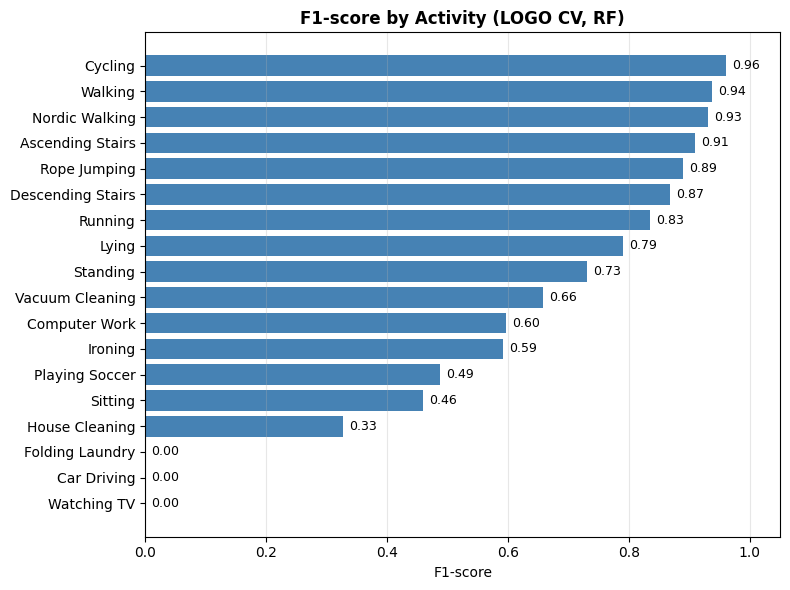

In [47]:
df_f1_logo = plot_f1_by_activity(rf_report_LeaveOneGroupOut, title="F1-score by Activity (LOGO CV, RF)")

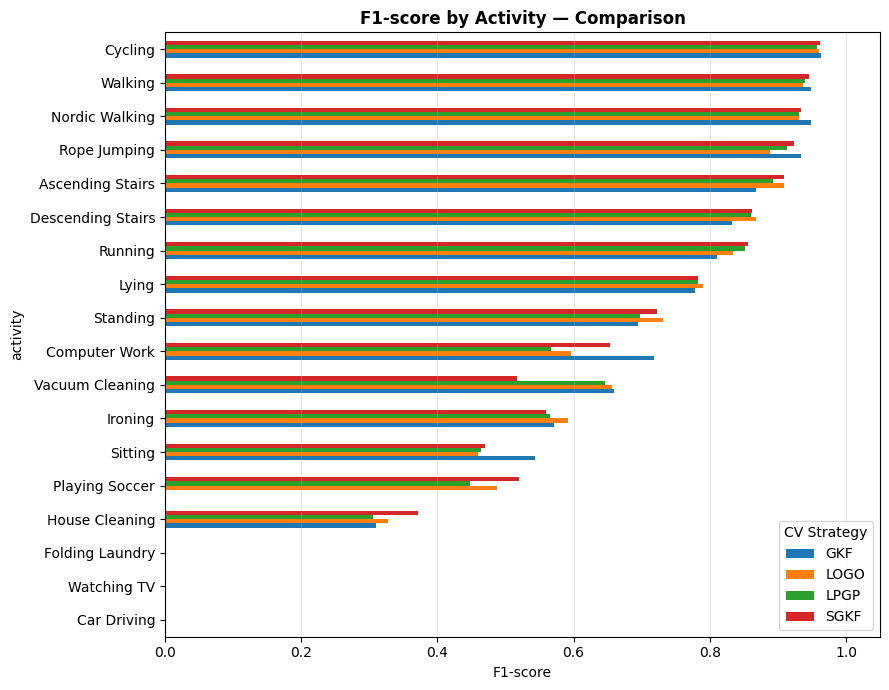

strategy,GKF,LOGO,LPGP,SGKF
activity,,,,
Car Driving,0.000000,0.000000,0.000000,0.000000
Watching TV,0.000000,0.000000,0.000000,0.000000
Folding Laundry,0.000000,0.000000,0.000498,0.000000
House Cleaning,0.309880,0.327573,0.304965,0.372354
Playing Soccer,0.000000,0.487973,0.448261,0.520000
Sitting,0.542708,0.459711,0.463405,0.469838
Ironing,0.571559,0.592159,0.565738,0.559667
Vacuum Cleaning,0.659975,0.657213,0.645726,0.516566
Computer Work,0.717738,0.596594,0.566584,0.653080


In [48]:
plot_f1_comparison({
    "GKF": rf_report_groupKFold,
    "SGKF": rf_report_StratifiedGroupKFold,
    "LPGP": rf_report_LeavePGroupsOut,
    "LOGO": rf_report_LeaveOneGroupOut
})

**LR**

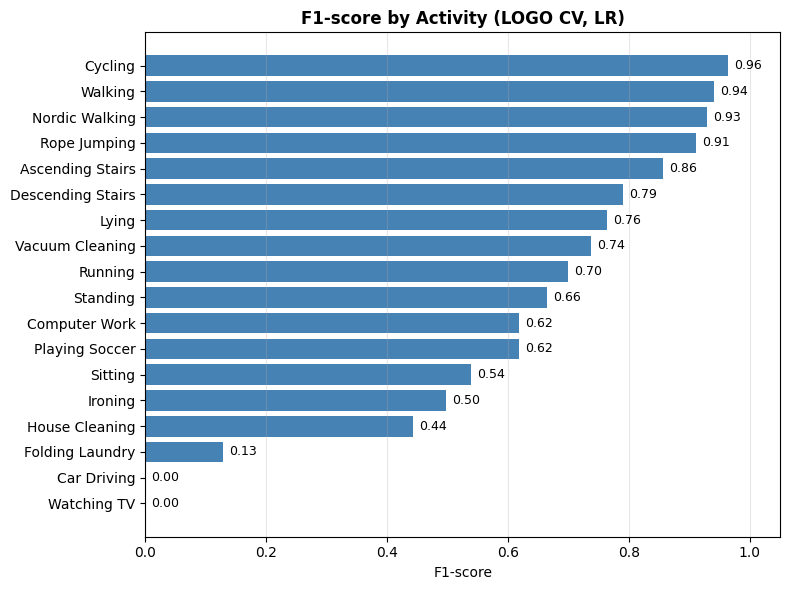

In [49]:
df_f2_logo = plot_f1_by_activity(lr_report_LeaveOneGroupOut, title="F1-score by Activity (LOGO CV, LR)")

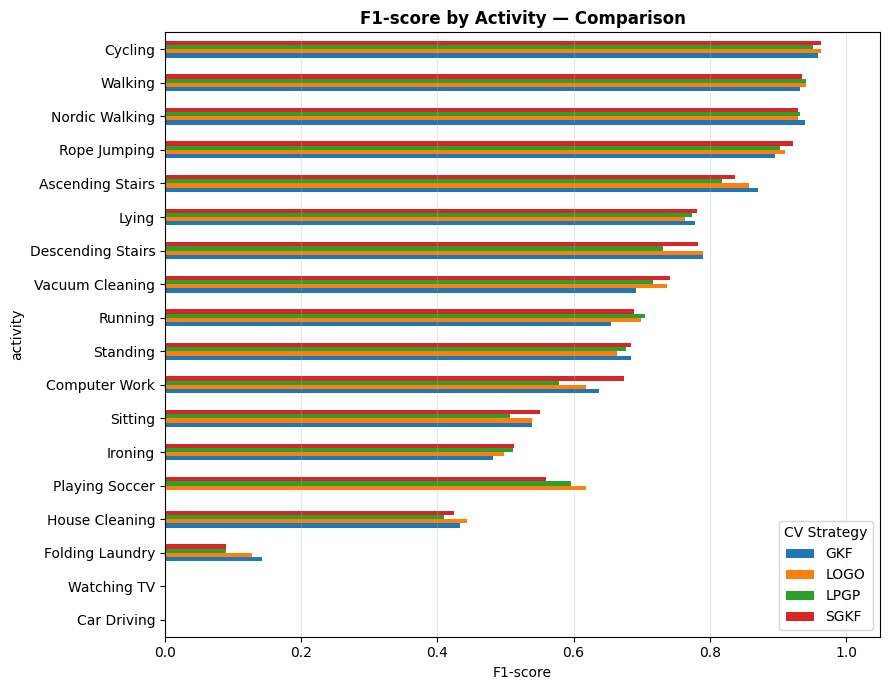

strategy,GKF,LOGO,LPGP,SGKF
activity,,,,
Car Driving,0.000000,0.000000,0.000000,0.000000
Watching TV,0.000000,0.000000,0.000000,0.000000
Folding Laundry,0.142308,0.128514,0.089013,0.088983
House Cleaning,0.433483,0.443343,0.410081,0.423851
Playing Soccer,0.000000,0.617737,0.596921,0.559486
Ironing,0.482443,0.497366,0.511699,0.512111
Sitting,0.539228,0.538556,0.506557,0.550447
Computer Work,0.636678,0.618978,0.579232,0.673422
Standing,0.684973,0.664032,0.677373,0.684910


In [50]:
plot_f1_comparison({
    "GKF": lr_report_groupKFold,
    "SGKF": lr_report_StratifiedGroupKFold,
    "LPGP": lr_report_LeavePGroupsOut,
    "LOGO": lr_report_LeaveOneGroupOut
})